In [17]:
import pandas as pd
import numpy as np
import torch as t
import torch.nn as nn
from torch.optim import Adam as Adam
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [18]:
example_data = pd.read_csv('../data/2/exp02H20141127_16h29.csv')

In [19]:
diffs = example_data.diff().dropna()

v1 = np.sqrt(diffs['X1']**2 + diffs['Y1']**2)
h1 = diffs['H1']

v2 = np.sqrt(diffs['X2']**2 + diffs['Y2']**2)
h2 = diffs['H2']

example_data['V1'] = v1
example_data['V2'] = v2
example_data['AV1'] = h1
example_data['AV2'] = h2


target_df = example_data[['V1', 'V2', 'AV1', 'AV2']]

target_df = target_df.dropna()
target_df = target_df.to_numpy()

In [20]:
def create_sequences(data, window_size = 30):

    shape = data.shape

    X = np.zeros((shape[1], shape[0]-window_size, window_size))
    y = np.zeros((shape[1], shape[0]-window_size))

    for c in range(shape[1]):

        for i in range(len(data) - window_size):

            X[c,i] = data[i : i + window_size, c]
            
            y[c,i] = data[i + window_size, c]

    X = X.transpose(1, 2, 0)
    
    y = y.transpose(1, 0)

    return X, y

In [21]:
from sklearn.preprocessing import StandardScaler

def prepare_fish_data(target_df, window_size=30, train_pct=0.7, val_pct=0.15):
    '''
    Splits the data into training, validation and testing by percentage. 
    Applies a scalar to normalise the data with mean 0 and std 1
    returns the splits for X and y, (sequence and next value) and the scalar
    '''
    n = len(target_df)
    train_end = int(n * train_pct)
    val_end = int(n * (train_pct + val_pct))
    
    raw_train = target_df[:train_end]
    raw_val = target_df[train_end:val_end]
    raw_test = target_df[val_end:]
    
    scaler = StandardScaler() # Found online, pretty easy to use and makes training much more efficent.
    train_scaled = scaler.fit_transform(raw_train)
    val_scaled = scaler.transform(raw_val)
    test_scaled = scaler.transform(raw_test)
    
    X_train, y_train = create_sequences(train_scaled, window_size)
    X_val, y_val = create_sequences(val_scaled, window_size)
    X_test, y_test = create_sequences(test_scaled, window_size)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_fish_data(target_df)

y_train = y_train[:, [0, 2]] 
y_test = y_test[:, [0, 2]]
y_val = y_val[:, [0, 2]]
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Train: (132993, 30, 4), (132993, 2)
Val:   (28475, 30, 4), (28475, 2)
Test:  (28476, 30, 4), (28476, 2)


In [22]:
class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        '''
        For any layer there is a weight between all the in features and out features
        There is also a bias, initially these are all normally distributed
        '''
        super().__init__()
        
        #tune down starting weigths and biases bc first training loop gave massive loss
        self.weights = nn.Parameter(t.randn(in_features, out_features, requires_grad=True)*0.01) 
        self.biases  = nn.Parameter(t.zeros(out_features, requires_grad=True))

    def forward(self, x):
        '''
        Here, x is basically the input layer values and it returns the output layer values
        '''
        # print(f"self.weights.shape = {self.weights.shape}")
        # print(f"self.biases.shape = {self.biases.shape}")
        # print(f"x.shape = {x.shape}")
        return x @ self.weights + self.biases

In [23]:
class MyNet(nn.Module):
    def __init__(self, in_features, hidden_features1, hidden_features2, out_features):
        super().__init__()
        '''
        This nn has one hidden layer between input and output
        '''
        self.layer1 = MyLinear(in_features, hidden_features1)
        self.layer2 = MyLinear(hidden_features1, hidden_features2)
        self.layer3 = MyLinear(hidden_features2, out_features)

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        '''
        Whne calling self.layer 1, this has already been initialised so uses the forward function in MyLinear.
        x is the input layer so this passes the input through the nn, applying the weights and biases to get the output.
        '''
        x = x.reshape(x.shape[0], -1) # (batch_size, 30, 4) -> (batch_size, 120)

        x = self.layer1(x)
        x = t.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = t.relu(x)
        x = self.dropout(x)
        
        x = self.layer3(x)
        return x

In [24]:
def loss(predictions, targets):
    # Calculates MSE
    return t.mean((predictions - targets) ** 2)

In [25]:
X_train_t = t.tensor(X_train, dtype=t.float32)
y_train_t = t.tensor(y_train, dtype=t.float32)
X_val_t = t.tensor(X_val, dtype=t.float32)
y_val_t = t.tensor(y_val, dtype=t.float32)
'''
learning_rate = 0.001
epochs = 100
mynet = MyNet(120, 256, 128, 4)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

optimizer = Adam(mynet.parameters(), lr=learning_rate, weight_decay=1e-4)

for epoch in range(epochs):
    mynet.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass: pass in X_train_t, not X!
        prediction = mynet(batch_X) 
        
        # Calculate loss: compare predictions to y_train_t
        L = loss(prediction, batch_y)
        
        # Backward pass
        L.backward()
        
        # Update weights
        optimizer.step()
        
    if epoch % 10 == 0:
        mynet.eval()
        with t.no_grad():
            full_train_pred = mynet(X_train_t)
            train_loss = loss(full_train_pred, y_train_t)

            val_prediction = mynet(X_val_t)
            val_loss = loss(val_prediction, y_val_t)
        print(f"Epoch {epoch} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
'''

'\nlearning_rate = 0.001\nepochs = 100\nmynet = MyNet(120, 256, 128, 4)\n\ntrain_dataset = TensorDataset(X_train_t, y_train_t)\ntrain_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)\n\noptimizer = Adam(mynet.parameters(), lr=learning_rate, weight_decay=1e-4)\n\nfor epoch in range(epochs):\n    mynet.train()\n    for batch_X, batch_y in train_loader:\n        optimizer.zero_grad()\n        \n        # Forward pass: pass in X_train_t, not X!\n        prediction = mynet(batch_X) \n        \n        # Calculate loss: compare predictions to y_train_t\n        L = loss(prediction, batch_y)\n        \n        # Backward pass\n        L.backward()\n        \n        # Update weights\n        optimizer.step()\n        \n    if epoch % 10 == 0:\n        mynet.eval()\n        with t.no_grad():\n            full_train_pred = mynet(X_train_t)\n            train_loss = loss(full_train_pred, y_train_t)\n\n            val_prediction = mynet(X_val_t)\n            val_loss = loss(val_pre

In [26]:
import torch as t
import torch.nn as nn

class MyLSTMNet(nn.Module):
    def __init__(self, input_features, hidden_size, out_features):
        super().__init__()
        
        # 1. The LSTM Layer
        # input_features = 4 (because each time step has 4 variables: V1, V2, AV1, AV2)
        # batch_first=True is CRITICAL: it tells PyTorch your shape is (batch, seq, feature)
        self.lstm = nn.LSTM(
            input_size=input_features, 
            hidden_size=hidden_size, 
            num_layers=1,       # You can increase this to 2 or 3 for a "deeper" LSTM
            batch_first=True 
        )
        
        # 2. Regularization (reduce overfitting)
        self.dropout = nn.Dropout(p=0.2)
        
        # 3. The Output Layer
        # This takes the final "thought" (hidden state) from the LSTM and maps it to our 4 predictions
        self.fc = nn.Linear(hidden_size, out_features)

    def forward(self, x):
        # Input 'x' shape is perfectly (batch_size, 30, 4)
        
        # The LSTM outputs two things:
        # lstm_out: The hidden states for ALL 30 time steps
        # (hn, cn): The final hidden and cell states at the very end
        lstm_out, (hn, cn) = self.lstm(x)
        
        # We only care about what the network is thinking at the VERY LAST time step (step 30)
        # because we are trying to predict what happens at step 31.
        # [:, -1, :] means -> [all batches, the last time step, all hidden features]
        last_time_step = lstm_out[:, -1, :] 
        
        # Apply dropout and pass through the final linear layer
        x = self.dropout(last_time_step)
        predictions = self.fc(x)
        
        return predictions

The LSTM (long short term memory) code is 90% gemini, it recomended it as its designed to deal with sequences but i havnt seen it before but its working and doing well. 

It would be good to add more data for it to train on but need to remember to deal with the scaling differently as the diff files will have slightly different mean and std which will throw the model off. (dk how to deal with it yet)

In [27]:
device = t.device("mps" if t.backends.mps.is_available() else "cpu")
print(f"Training on device: {device}") # This should print "mps"!

# input_features=4, hidden_size=128 (memory capacity), out_features=4
mynet = MyLSTMNet(input_features=4, hidden_size=128, out_features=2)
mynet = mynet.to(device)
# Keep your weight decay!
optimizer = t.optim.Adam(mynet.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 80

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

noise_level = 0.05

for epoch in range(epochs):
    mynet.train()
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        noisy_batch_X = batch_X + (t.randn_like(batch_X) * noise_level)
        
        optimizer.zero_grad()
        prediction = mynet(noisy_batch_X)

        L = loss(prediction, batch_y)
        L.backward()
        optimizer.step()
        
    if epoch % 10 == 0:
        mynet.eval()
        with t.no_grad():
            val_X_gpu = X_val_t.to(device)
            val_y_gpu = y_val_t.to(device)
            
            val_prediction = mynet(val_X_gpu)
            val_loss = loss(val_prediction, val_y_gpu)

        print(f"Epoch {epoch} | Val Loss: {val_loss.item():.4f}")

Training on device: mps
Epoch 0 | Val Loss: 0.2128
Epoch 10 | Val Loss: 0.1879
Epoch 20 | Val Loss: 0.1769
Epoch 30 | Val Loss: 0.1711
Epoch 40 | Val Loss: 0.1685
Epoch 50 | Val Loss: 0.1670
Epoch 60 | Val Loss: 0.1686
Epoch 70 | Val Loss: 0.1666


In [28]:
import torch as t
import numpy as np

def simulate_rollout(model, initial_seed, true_neighbor_future, steps_to_predict, device):
    """
    Simulates a fish's trajectory by feeding predictions back into the model.
    
    Args:
        model: Your trained PyTorch LSTM model.
        initial_seed: Tensor of shape (1, 30, 4) - The starting 30-step history.
        true_neighbor_future: Tensor of shape (steps_to_predict, 2) - The actual future V and AV of the neighbor.
        steps_to_predict: Integer - How many steps into the future to simulate.
        device: 'mps' or 'cpu'.
        
    Returns:   
        A list of the predicted target movements (V, AV) for the simulated steps.
    """
    model.eval()
    
    # Clone the seed so we don't accidentally modify our original test dataset
    current_window = initial_seed.clone().to(device)
    
    predicted_path = []
    
    with t.no_grad():
        for i in range(steps_to_predict):
            
            # 1. Predict the target fish's next move (Shape: 1 batch, 2 features)
            target_pred = model(current_window)
            
            # Save the prediction for our final output
            predicted_path.append(target_pred.cpu().numpy().flatten())
            
            # 2. Grab the actual neighbor data for this specific future step
            # Shape: (2 features) -> Expand to (1 batch, 2 features) to match the prediction
            # 2. Grab the actual neighbor data (V2, AV2)
            neighbor_actual = true_neighbor_future[i].unsqueeze(0).to(device)
            
            # 3. Assemble the new time step exactly as [V1, V2, AV1, AV2]
            new_step = t.stack([
                target_pred[:, 0],       # V1 (Predicted)
                neighbor_actual[:, 0],   # V2 (Actual)
                target_pred[:, 1],       # AV1 (Predicted)
                neighbor_actual[:, 1]    # AV2 (Actual)
            ], dim=1)

            new_step = new_step.unsqueeze(1)
            
            # 4. Slide the window
            # Keep batches ([:, ...]), drop the first time step (1:, ...), keep all features (:, :])
            current_window = current_window[:, 1:, :]
            
            # Append the newly created step to the end of the window
            current_window = t.cat([current_window, new_step], dim=1)
            
    return np.array(predicted_path)

In [29]:
X_test_t = t.tensor(X_test, dtype=t.float32)

# Number of steps to simulate
n_steps = 100 

# 1. The Seed: The first 30-step sequence from your test set, reshaped to include the batch dimension
seed_sequence = X_test_t[0].unsqueeze(0) # Shape: (1, 30, 4)

# 2. The Future: The actual neighbor data for the next 100 steps
# Assuming columns 2 and 3 are the Neighbor V and AV
neighbor_future_data = X_test_t[1 : n_steps + 1, -1, [1, 3]]

# 3. Run the simulation
predicted_trajectory = simulate_rollout(
    model=mynet, 
    initial_seed=seed_sequence, 
    true_neighbor_future=neighbor_future_data, 
    steps_to_predict=n_steps, 
    device=device
)

In [30]:
def reconstruct_and_plot(predicted_path, scaler, true_start_state, true_full_XY_path):
    """
    Un-scales predictions and reconstructs the X, Y coordinates for plotting.
    
    Args:
        predicted_path: Numpy array of shape (steps, 2) containing [Predicted_V1, Predicted_AV1]
        scaler: Your fitted StandardScaler object
        true_start_state: Tuple of the actual starting (X, Y, Heading) at the moment the simulation begins
        true_full_XY_path: Numpy array of the actual X, Y coordinates to plot against
    """
    
    # --- 1. THE DUMMY ARRAY TRICK (UN-SCALING) ---
    # Create an array of zeros with 4 columns (matching V1, V2, AV1, AV2)
    dummy_array = np.zeros((predicted_path.shape[0], 4))
    
    # Slot your predictions into the V1 (index 0) and AV1 (index 2) columns
    dummy_array[:, 0] = predicted_path[:, 0] 
    dummy_array[:, 2] = predicted_path[:, 1] 
    
    # Inverse transform
    unscaled_data = scaler.inverse_transform(dummy_array)
    
    # Extract the true unscaled speeds and heading changes
    pred_V = unscaled_data[:, 0]
    pred_AV = unscaled_data[:, 2]
    
    
    # --- 2. RECONSTRUCTING COORDINATES (UN-DERIVING) ---
    X, Y, H = true_start_state
    
    pred_X_list = [X]
    pred_Y_list = [Y]
    
    for i in range(len(pred_V)):
        # 1. Update the Heading
        H = H + pred_AV[i]
        
        # Note: np.cos and np.sin expect RADIANS. 
        # If your original Heading data was in DEGREES, uncomment the line below:
        # H_rad = np.radians(H) 
        H_rad = H 
        
        # 2. Calculate the new X and Y based on speed and heading
        X = X + (pred_V[i] * np.cos(H_rad))
        Y = Y + (pred_V[i] * np.sin(H_rad))
        
        pred_X_list.append(X)
        pred_Y_list.append(Y)
        
        
    # --- 3. PLOTTING ---
    plt.figure(figsize=(10, 8))
    
    # Plot True Path
    plt.plot(true_full_XY_path[:, 0], true_full_XY_path[:, 1], 
             label="True Path", color="blue", alpha=0.5, linewidth=2)
    
    # Plot Predicted Path
    plt.plot(pred_X_list, pred_Y_list, 
             label="LSTM Predicted Path", color="red", linestyle="--", linewidth=2)
    
    # Mark the start point
    plt.scatter([pred_X_list[0]], [pred_Y_list[0]], 
                color="green", s=100, zorder=5, label="Simulation Start")
    
    plt.title("Autoregressive Simulation: Fish Trajectory")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

In [31]:
# 1. Recalculate where the Test set started in your original data
n = len(example_data)
train_pct = 0.70
val_pct = 0.15

# This is the exact row index in example_data where the Test set begins
val_end_idx = int(n * (train_pct + val_pct))

# 2. Account for the 30-step window
window_size = 30

# The simulation starts predicting the step right AFTER the 30-step seed.
# So our "anchor" state is the very last step of that seed.
start_index = val_end_idx + window_size - 1

# --- GET THE TRUE START STATE ---
# Assuming columns X1, Y1, H1 are the target fish
true_start_X = example_data.iloc[start_index]['X1']
true_start_Y = example_data.iloc[start_index]['Y1']
true_start_H = example_data.iloc[start_index]['H1']

true_start_state = (true_start_X, true_start_Y, true_start_H)

# --- GET THE TRUE FULL XY PATH ---
# We want the actual X and Y coordinates for the exact number of steps we simulated
n_steps_to_simulate = 100

# The path starts at the step we are predicting (start_index + 1)
path_start = start_index + 1
path_end = path_start + n_steps_to_simulate

true_full_XY_path = example_data.iloc[path_start : path_end][['X1', 'Y1']].to_numpy()

print(f"Start State: X={true_start_X:.2f}, Y={true_start_Y:.2f}, Heading={true_start_H:.2f}")
print(f"Path Shape: {true_full_XY_path.shape} (Should be {n_steps_to_simulate}, 2)")

Start State: X=-156.83, Y=-288.73, Heading=307.70
Path Shape: (100, 2) (Should be 100, 2)


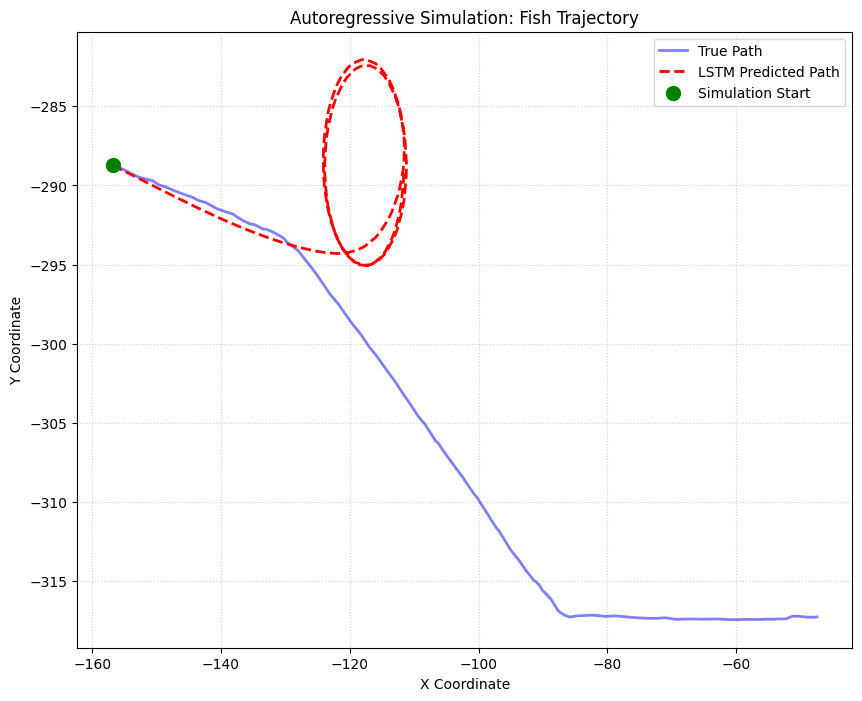

In [32]:
reconstruct_and_plot(predicted_trajectory, scaler, true_start_state, true_full_XY_path)